In [1]:
import numpy as np
import pandas as pd
import utils
import pickle

from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [2]:
# Get the cleaned dataset
with open(f'data/dataset_clean.pkl', 'rb') as file:
    X_train, X_val, X_test, y_train, y_val, y_test = pickle.load(file)['retval']

In [3]:
# Create a tuning subset
X_tune, _, y_tune, _ = train_test_split(X_train, y_train, train_size=100000, random_state=42)

# Build a Pipeline (scalar + model)
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('knn', KNeighborsRegressor())
])

# Define the hyperparameter search space
knn_param_grid = {
    'knn__n_neighbors': [25, 50, 100, 150], 
    'knn__algorithm': ['kd_tree', 'ball_tree'],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] 
}

# Run the search using custom function
knn_search, best_params, best_score = utils.optimize_hyper_params(knn_pipeline, X_tune, y_tune, knn_param_grid, 'grid')

# Print the metrics
print("\nBEST PARAMETERS: ", best_params)
print(f"BEST CV RMSE:    {-best_score:.16f}")

----- Running GridSearchCV -----
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/Users/manthanp/astroML/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Total Runtime: 1.3048 minutes

BEST PARAMETERS:  {'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}
BEST CV RMSE:    0.0233276714508581


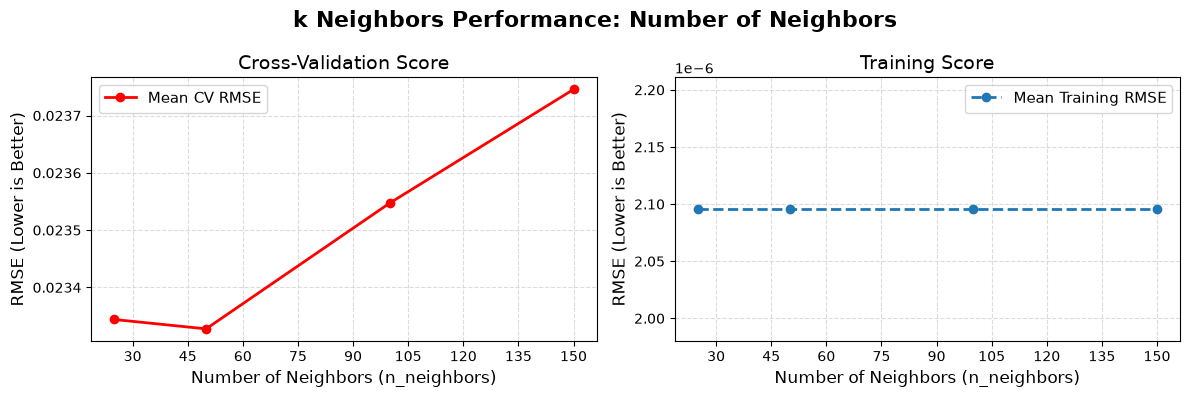

In [4]:
# Plot RMSE vs. Number of Neighbors
utils.plot_side_by_side_diagnostics(
    search=knn_search, 
    param_name='knn__n_neighbors', 
    suptitle='k Neighbors Performance: Number of Neighbors',
    xlabel_text='Number of Neighbors (n_neighbors)'
)

In [5]:
# Train a new model with the optimial hyperparameters on the full training set
clean_params = {key.replace('knn__', ''): value for key, value in best_params.items()}
knn_final = KNeighborsRegressor(**clean_params, n_jobs=-1)
knn_final.fit(X_train, y_train)

# Make predictions on the validation set
z_pred_val = knn_final.predict(X_val)

# Calculate and print the metrics
print( "-" * 4, f"Validation Dataset Metrics", "-" * 4)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_val, y_val):.16f}")
print(f"Bias:             {utils.bias(z_pred_val, y_val):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_val, y_val):.16f}")
print("-" * 36)

---- Validation Dataset Metrics ----
Outlier Fraction: 0.0256604383069360
Bias:             0.0003476790979766
NMAD:             0.0163725930608235
------------------------------------


In [6]:
# TESTING THE FINAL MODEL
print("=" * 36)
print("FINAL TEST SET EVALUATION")
print(f"Using Hyperparameters: \n{best_params}")
print("=" * 36 + "\n")

# Combine train and val data since we don't need the val
X_train_combined = np.vstack((X_train, X_val))
y_train_combined = np.concatenate((y_train, y_val))

# Train the final model on the now bigger training set
knn_final.fit(np.array(X_train_combined), np.array(y_train_combined)) 

# Make predictions on the test set
z_pred_test = knn_final.predict(np.array(X_test))

# Calculate and print the final metrics
print( "-" * 7, f"Test Dataset Metrics", "-" * 7)
print(f"Outlier Fraction: {utils.outlier_fraction(z_pred_test, y_test):.16f}")
print(f"Bias:             {utils.bias(z_pred_test, y_test):.16f}")
print(f"NMAD:             {utils.nmad(z_pred_test, y_test):.16f}")
print("-" * 36)

FINAL TEST SET EVALUATION
Using Hyperparameters: 
{'knn__algorithm': 'kd_tree', 'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance'}

------- Test Dataset Metrics -------
Outlier Fraction: 0.0247415812000323
Bias:             0.0003288368056216
NMAD:             0.0161929547051130
------------------------------------
